# Lab Assignment 4 — Logistic Regression
## Breast Cancer Wisconsin (Diagnostic) Dataset


## Imports and Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score
)

pd.set_option("display.max_columns", None)
sns.set_theme(style="whitegrid")


## Task 1 — Data Acquisition and Exploration

### 1.1 Download and Load the Dataset

In [2]:
# Download the dataset from the UCI Machine Learning Repository
breast_cancer = fetch_ucirepo(id=17)

# Separate features and target
X = breast_cancer.data.features.copy()
y = breast_cancer.data.targets.copy()

# Combine them for exploration
df = pd.concat([X, y], axis=1)

print("Dataset shape:", df.shape)
display(df.head())


Dataset shape: (569, 31)


,radius1,texture1,perimeter1,area1,smoothness1,compactness1,concavity1,concave_points1,symmetry1,fractal_dimension1,radius2,texture2,perimeter2,area2,smoothness2,compactness2,concavity2,concave_points2,symmetry2,fractal_dimension2,radius3,texture3,perimeter3,area3,smoothness3,compactness3,concavity3,concave_points3,symmetry3,fractal_dimension3,Diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,M
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,M
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,M
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,M
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,M


### 1.2 Basic Dataset Information

In [3]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

print("\nColumn names:")
print(df.columns.tolist())

print("\nData types:")
display(df.dtypes)


Number of rows: 569
Number of columns: 31

Column names:
['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2', 'compactness2', 'concavity2', 'concave_points2', 'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3', 'Diagnosis']

Data types:


radius1               float64
texture1              float64
perimeter1            float64
area1                 float64
smoothness1           float64
compactness1          float64
concavity1            float64
concave_points1       float64
symmetry1             float64
fractal_dimension1    float64
radius2               float64
texture2              float64
perimeter2            float64
area2                 float64
smoothness2           float64
compactness2          float64
concavity2            float64
concave_points2       float64
symmetry2             float64
fractal_dimension2    float64
radius3               float64
texture3              float64
perimeter3            float64
area3                 float64
smoothness3           float64
compactness3          float64
concavity3            float64
concave_points3       float64
symmetry3             float64
fractal_dimension3    float64
Diagnosis              object
dtype: object

### 1.3 Summary Statistics

In [4]:
# Summary statistics for all numerical features
display(X.describe().T)

# Additional median values
median_values = X.median().to_frame(name="median")
display(median_values)


,count,mean,std,min,25%,50%,75%,max
radius1,569.0,14.127292,3.524049,6.981000,11.700000,13.370000,15.780000,28.11000
texture1,569.0,19.289649,4.301036,9.710000,16.170000,18.840000,21.800000,39.28000
perimeter1,569.0,91.969033,24.298981,43.790000,75.170000,86.240000,104.100000,188.50000
area1,569.0,654.889104,351.914129,143.500000,420.300000,551.100000,782.700000,2501.00000
smoothness1,569.0,0.096360,0.014064,0.052630,0.086370,0.095870,0.105300,0.16340
compactness1,569.0,0.104341,0.052813,0.019380,0.064920,0.092630,0.130400,0.34540
concavity1,569.0,0.088799,0.079720,0.000000,0.029560,0.061540,0.130700,0.42680
concave_points1,569.0,0.048919,0.038803,0.000000,0.020310,0.033500,0.074000,0.20120
symmetry1,569.0,0.181162,0.027414,0.106000,0.161900,0.179200,0.195700,0.30400
fractal_dimension1,569.0,0.062798,0.007060,0.049960,0.057700,0.061540,0.066120,0.09744


,median
radius1,13.370000
texture1,18.840000
perimeter1,86.240000
area1,551.100000
smoothness1,0.095870
compactness1,0.092630
concavity1,0.061540
concave_points1,0.033500
symmetry1,0.179200
fractal_dimension1,0.061540


### 1.4 Check Missing Values

In [5]:
missing_values = df.isnull().sum()

print("Missing values in each column:")
display(missing_values[missing_values > 0])

if missing_values.sum() == 0:
    print("No missing values found in the dataset.")


Missing values in each column:


Series([], dtype: int64)

No missing values found in the dataset.


### 1.5 Check Duplicate Records

In [6]:
duplicate_count = df.duplicated().sum()
print("Number of duplicate rows:", duplicate_count)

if duplicate_count > 0:
    df = df.drop_duplicates().reset_index(drop=True)
    print("Duplicates removed.")
else:
    print("No duplicate rows found.")


Number of duplicate rows: 0
No duplicate rows found.


### 1.6 Detect Outliers Using the IQR Method

In [7]:
# Detect potential outliers using the Interquartile Range (IQR)
Q1 = X.quantile(0.25)
Q3 = X.quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

outlier_counts = ((X < lower_bound) | (X > upper_bound)).sum().sort_values(ascending=False)

print("Potential outliers by feature:")
display(outlier_counts.to_frame(name="outlier_count"))


Potential outliers by feature:


,outlier_count
area2,65
radius2,38
perimeter2,38
area3,35
smoothness2,30
fractal_dimension2,28
compactness2,28
symmetry2,27
area1,25
fractal_dimension3,24


### Outlier Handling

### 1.7 Visualize Feature Distributions

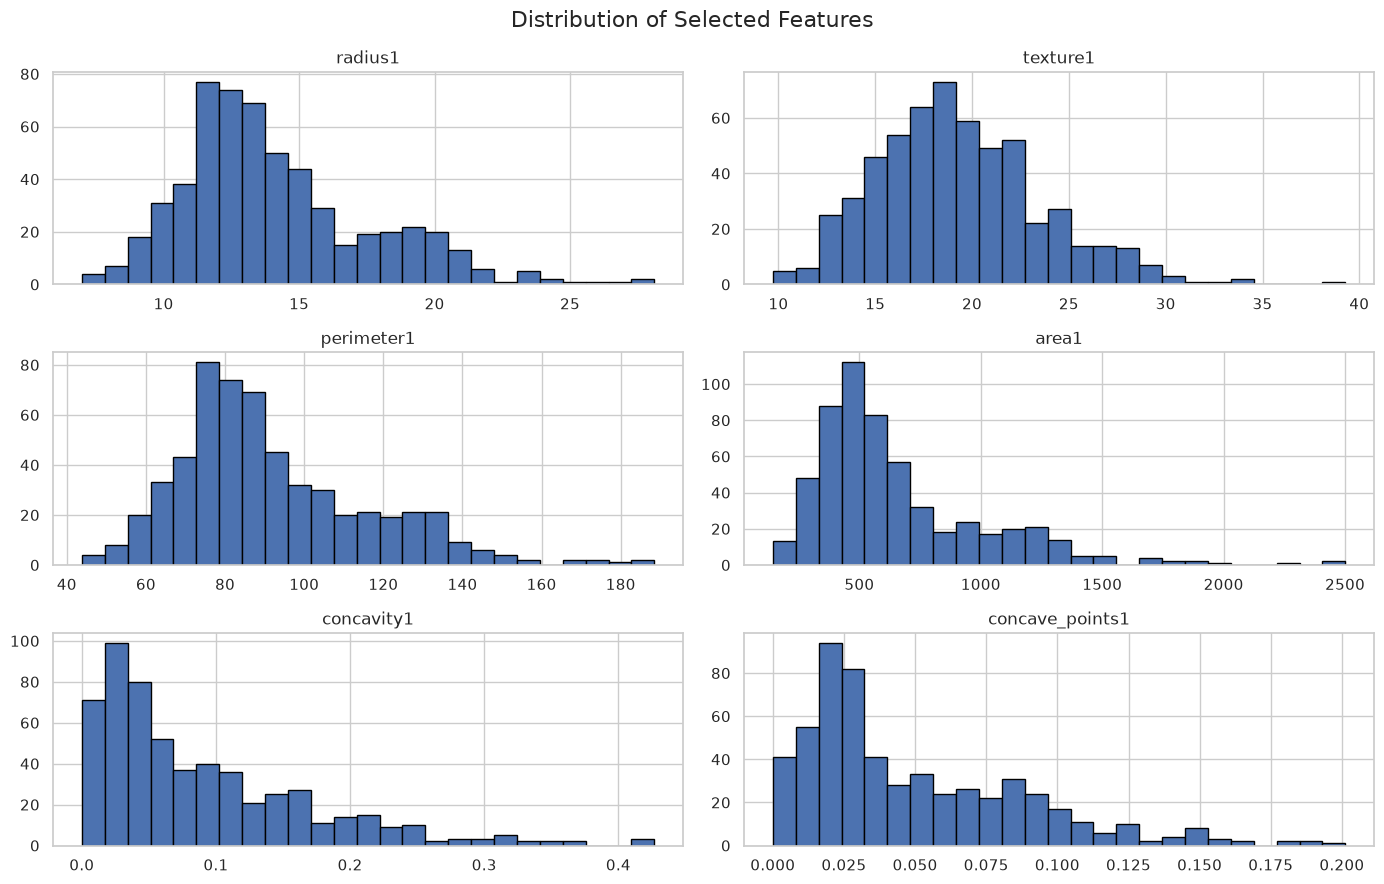

In [8]:
# Histograms for selected important features
selected_features = ["radius1", "texture1", "perimeter1", "area1", "concavity1", "concave_points1"]

X[selected_features].hist(figsize=(14, 9), bins=25, edgecolor="black")
plt.suptitle("Distribution of Selected Features", fontsize=16)
plt.tight_layout()
plt.show()


### 1.8 Box Plots for Outlier Visualization

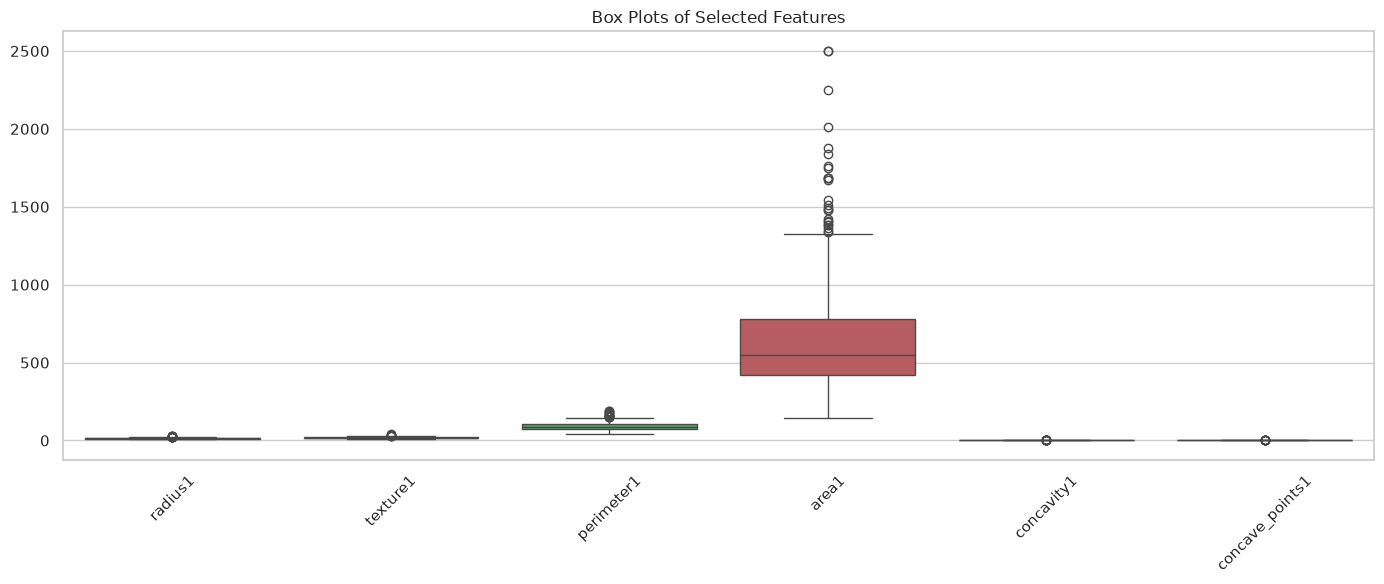

In [9]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=X[selected_features])
plt.xticks(rotation=45)
plt.title("Box Plots of Selected Features")
plt.tight_layout()
plt.show()


### 1.9 Correlation Heatmap

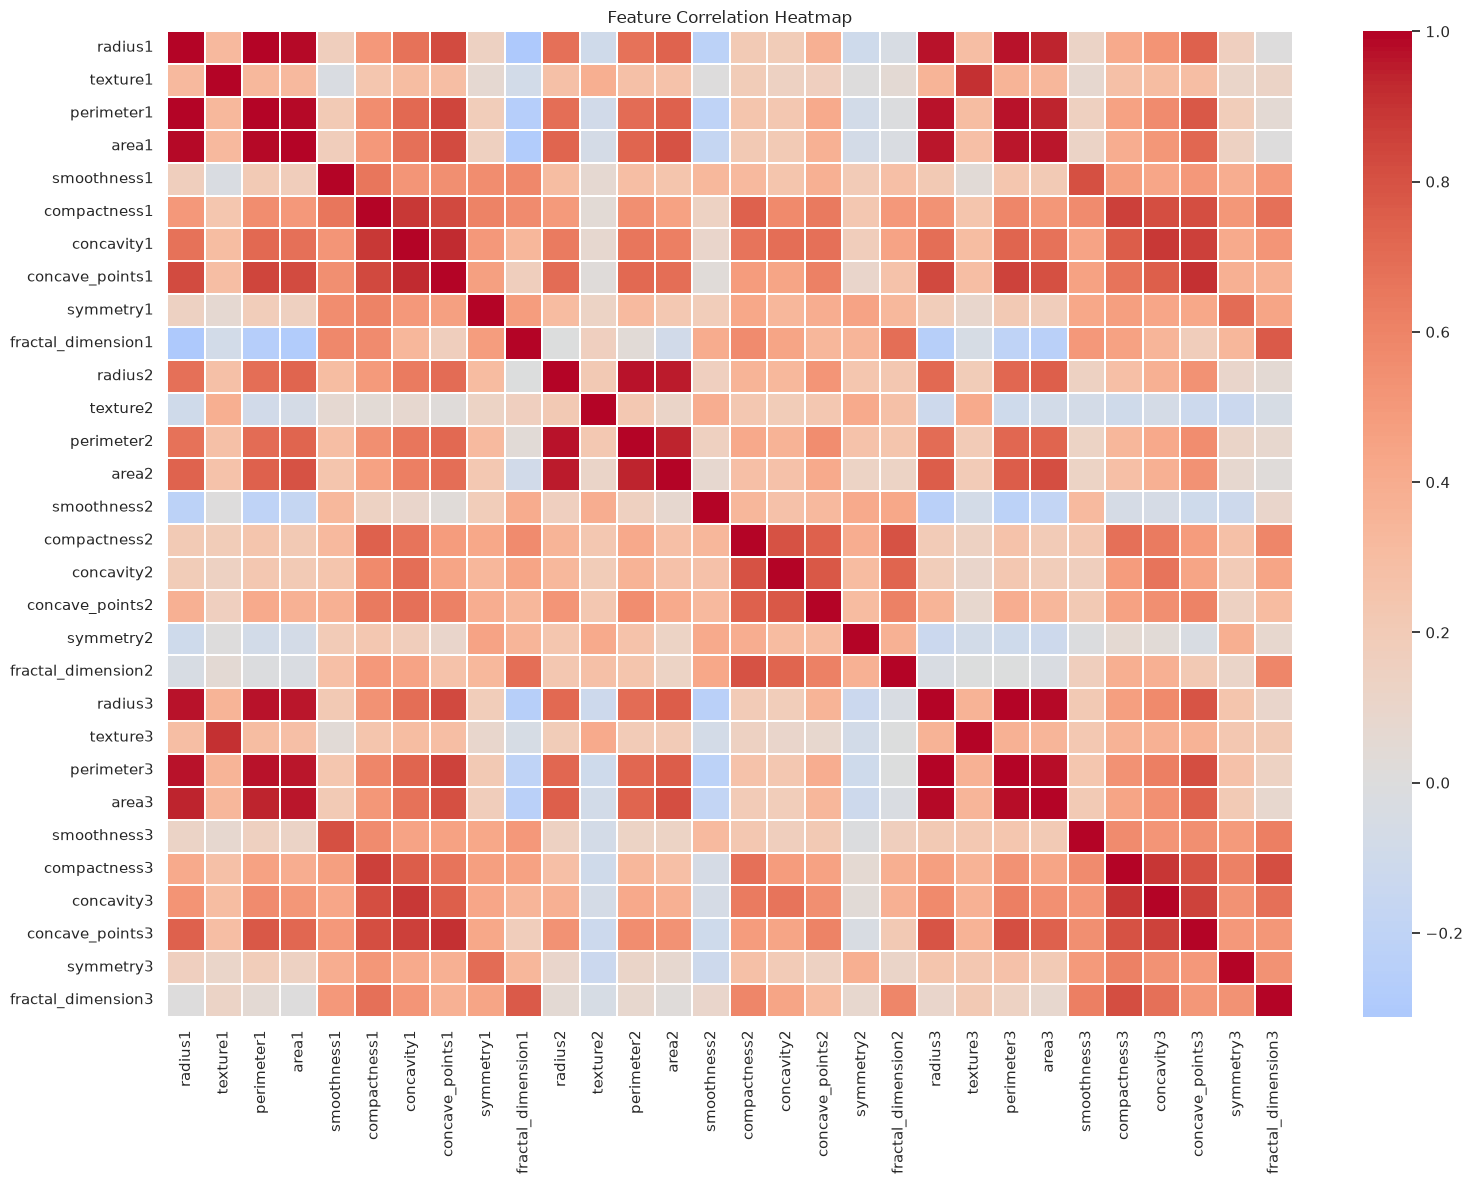

In [10]:
plt.figure(figsize=(16, 12))
correlation_matrix = X.corr()

sns.heatmap(
    correlation_matrix,
    cmap="coolwarm",
    center=0,
    linewidths=0.2
)

plt.title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()


### 1.10 Class Distribution

Class distribution:


Diagnosis
B    357
M    212
Name: count, dtype: int64

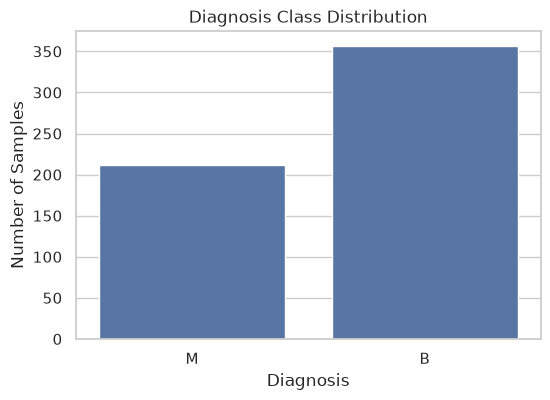

In [11]:
class_counts = y.iloc[:, 0].value_counts()

print("Class distribution:")
display(class_counts)

plt.figure(figsize=(6, 4))
sns.countplot(x=y.iloc[:, 0])
plt.title("Diagnosis Class Distribution")
plt.xlabel("Diagnosis")
plt.ylabel("Number of Samples")
plt.show()


### Task 1 — Class Distribution Discussion

## Task 2 — Data Preprocessing

### 2.1 Encode the Target Variable as Binary

In [12]:
# Encode B = 0 (Benign), M = 1 (Malignant)
y_binary = y.iloc[:, 0].map({"B": 0, "M": 1})

print("Encoded target values:")
print(y_binary.value_counts().sort_index())

print("\nMapping:")
print("B (Benign)    -> 0")
print("M (Malignant) -> 1")


Encoded target values:
Diagnosis
0    357
1    212
Name: count, dtype: int64

Mapping:
B (Benign)    -> 0
M (Malignant) -> 1


### 2.2 Remove the ID Column

In [13]:
# ID is an identifier, not a clinical measurement, so it is excluded from modeling.
X_model = X.drop(columns=["ID"], errors="ignore")

print("Features used for modeling:", X_model.shape[1])
print(X_model.columns.tolist())


Features used for modeling: 30
['radius1', 'texture1', 'perimeter1', 'area1', 'smoothness1', 'compactness1', 'concavity1', 'concave_points1', 'symmetry1', 'fractal_dimension1', 'radius2', 'texture2', 'perimeter2', 'area2', 'smoothness2', 'compactness2', 'concavity2', 'concave_points2', 'symmetry2', 'fractal_dimension2', 'radius3', 'texture3', 'perimeter3', 'area3', 'smoothness3', 'compactness3', 'concavity3', 'concave_points3', 'symmetry3', 'fractal_dimension3']


### 2.3 Train-Test Split Using Stratified Sampling

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model,
    y_binary,
    test_size=0.20,
    random_state=42,
    stratify=y_binary
)

print("Training set:", X_train.shape)
print("Testing set :", X_test.shape)

print("\nTraining class proportions:")
print(y_train.value_counts(normalize=True))

print("\nTesting class proportions:")
print(y_test.value_counts(normalize=True))


Training set: (455, 30)
Testing set : (114, 30)

Training class proportions:
Diagnosis
0    0.626374
1    0.373626
Name: proportion, dtype: float64

Testing class proportions:
Diagnosis
0    0.631579
1    0.368421
Name: proportion, dtype: float64


### 2.4 Handle Outliers Using Training-Set IQR Limits

In [15]:
# Calculate IQR limits using ONLY the training data
Q1_train = X_train.quantile(0.25)
Q3_train = X_train.quantile(0.75)
IQR_train = Q3_train - Q1_train

lower_train = Q1_train - 1.5 * IQR_train
upper_train = Q3_train + 1.5 * IQR_train

# Clip both training and testing data using the training-derived limits
X_train_clean = X_train.clip(lower=lower_train, upper=upper_train, axis=1)
X_test_clean = X_test.clip(lower=lower_train, upper=upper_train, axis=1)

print("Outlier handling completed using training-set IQR limits.")


Outlier handling completed using training-set IQR limits.


### 2.5 Standardize the Features

In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train_clean)
X_test_scaled = scaler.transform(X_test_clean)

print("Standardization completed.")
print("Training data mean (approximately):", X_train_scaled.mean())
print("Training data standard deviation (approximately):", X_train_scaled.std())


Standardization completed.
Training data mean (approximately): 1.7763568394002505e-17
Training data standard deviation (approximately): 1.0


## Task 3 — Logistic Regression and Basic Evaluation

### 3.1 Train the Logistic Regression Model

In [17]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

logistic_model.fit(X_train_scaled, y_train)

print("Logistic Regression model trained successfully.")


Logistic Regression model trained successfully.


### 3.2 Generate Predictions

In [18]:
y_pred = logistic_model.predict(X_test_scaled)
y_prob = logistic_model.predict_proba(X_test_scaled)[:, 1]

print("First 10 predicted classes:", y_pred[:10])
print("First 10 malignant probabilities:", y_prob[:10])


First 10 predicted classes: [0 1 0 0 1 0 1 0 0 0]
First 10 malignant probabilities: [2.02352241e-04 9.99999992e-01 2.54992456e-02 4.72198191e-01
 5.22782023e-01 6.13005901e-04 8.03985180e-01 4.51440658e-04
 3.53345154e-04 7.38410153e-03]


### 3.3 Accuracy, Precision, Recall and F1-Score

In [19]:
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-score : {f1:.4f}")


Accuracy : 0.9649
Precision: 0.9750
Recall   : 0.9286
F1-score : 0.9512


### 3.4 Precision, Recall and F1-Score for Both Classes

In [20]:
print(classification_report(
    y_test,
    y_pred,
    target_names=["Benign (0)", "Malignant (1)"],
    digits=4
))


               precision    recall  f1-score   support

   Benign (0)     0.9595    0.9861    0.9726        72
Malignant (1)     0.9750    0.9286    0.9512        42

     accuracy                         0.9649       114
    macro avg     0.9672    0.9573    0.9619       114
 weighted avg     0.9652    0.9649    0.9647       114



### 3.5 Confusion Matrix

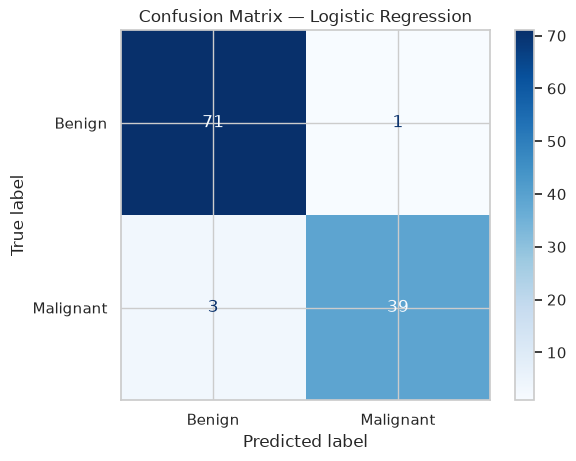

Confusion Matrix:
[[71  1]
 [ 3 39]]


In [21]:
cm = confusion_matrix(y_test, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot(cmap="Blues")
plt.title("Confusion Matrix — Logistic Regression")
plt.show()

print("Confusion Matrix:")
print(cm)


### 3.6 ROC Curve and AUC Score

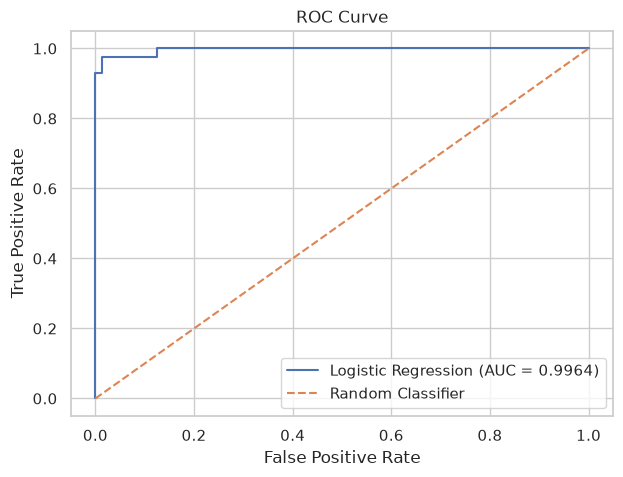

ROC-AUC Score: 0.9964


In [22]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"Logistic Regression (AUC = {auc_score:.4f})")
plt.plot([0, 1], [0, 1], linestyle="--", label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()
plt.show()

print(f"ROC-AUC Score: {auc_score:.4f}")


### 3.7 Final Evaluation Summary

In [23]:
results = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"],
    "Score": [accuracy, precision, recall, f1, auc_score]
})

display(results)


,Metric,Score
0,Accuracy,0.964912
1,Precision,0.975000
2,Recall,0.928571
3,F1-Score,0.951220
4,ROC-AUC,0.996362
